# **22장. 가치 기반 강화학습 - DQN**

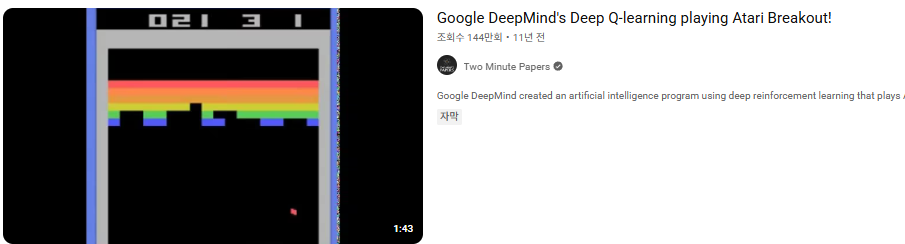

https://www.youtube.com/watch?v=V1eYniJ0Rnk

이 동영상은 구글 연구진이 개발한 **DQN** 모델이 벽돌깨기 게임을 학습하는 과정을 보여줍니다.

상태가 이미지이므로, **CNN** 모델을 사용하였습니다.

거의 모든 고전 아케이드 게임에서 다른 모델보다 압도적으로 높은 성능을 보여주었습니다.


---




[실습 22-01]

In [ ]:
!pip install koreanize_matplotlib
import koreanize_matplotlib
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym      # 환경 시뮬레이터 불러오기

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 55.4 MB/s eta 0:00:00


[실습 22-02]

In [ ]:
# 환경 정의 및 시각화 설정
env = gym.make("CartPole-v1", render_mode="rgb_array")

# 최대 스텝 수 제한(500 -> 100)
env = gym.wrappers.TimeLimit(env, max_episode_steps=100)

# 상태 초기화
상태, _ = env.reset()
print("초기 상태:", 상태)

초기 상태: [ 0.00640959  0.04915155 -0.04138016 -0.02137833]


[실습 22-03]

In [ ]:
상태, _ = env.reset()

for step in range(100):
  행동=np.random.randint(0, 2)  # 0 또는 1 무작위

  상태, 보상, terminated, truncated, _ = env.step(행동)

  종료=terminated or truncated

  print(f"스텝= {step:2}  | 행동={행동} | 상태={상태} | 보상={보상} | 종료={종료}")

  if 종료:
        break   # 반복문 탈출

스텝=  0  | 행동=0 | 상태=[-0.04402179 -0.20790958  0.00312034  0.26300648] | 보상=1.0 | 종료=False
스텝=  1  | 행동=0 | 상태=[-0.04817999 -0.40307593  0.00838047  0.556672  ] | 보상=1.0 | 종료=False
스텝=  2  | 행동=1 | 상태=[-0.0562415  -0.20807263  0.01951391  0.2666411 ] | 보상=1.0 | 종료=False
스텝=  3  | 행동=0 | 상태=[-0.06040296 -0.40346757  0.02484673  0.5654144 ] | 보상=1.0 | 종료=False
스텝=  4  | 행동=0 | 상태=[-0.06847231 -0.5989291   0.03615502  0.86582047] | 보상=1.0 | 종료=False
스텝=  5  | 행동=1 | 상태=[-0.08045089 -0.4043174   0.05347143  0.5847209 ] | 보상=1.0 | 종료=False
스텝=  6  | 행동=0 | 상태=[-0.08853724 -0.600146    0.06516585  0.8937571 ] | 보상=1.0 | 종료=False
스텝=  7  | 행동=1 | 상태=[-0.10054016 -0.40596548  0.08304099  0.6222498 ] | 보상=1.0 | 종료=False
스텝=  8  | 행동=1 | 상태=[-0.10865947 -0.21209526  0.09548599  0.3568325 ] | 보상=1.0 | 종료=False
스텝=  9  | 행동=0 | 상태=[-0.11290137 -0.40843588  0.10262264  0.6780321 ] | 보상=1.0 | 종료=False
스텝= 10  | 행동=0 | 상태=[-0.12107009 -0.6048225   0.11618327  1.0011804 ] | 보상=1.0 | 종료=False
스텝= 11  | 

[실습 22-04]

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)
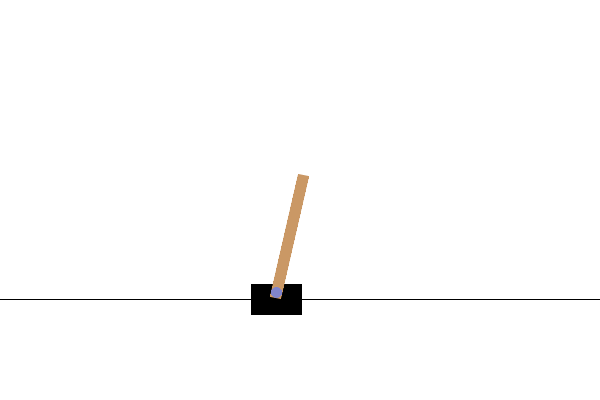

In [ ]:
frame = env.render()
frame

📌상태 변화 과정을 GIF 형태로 제작하기

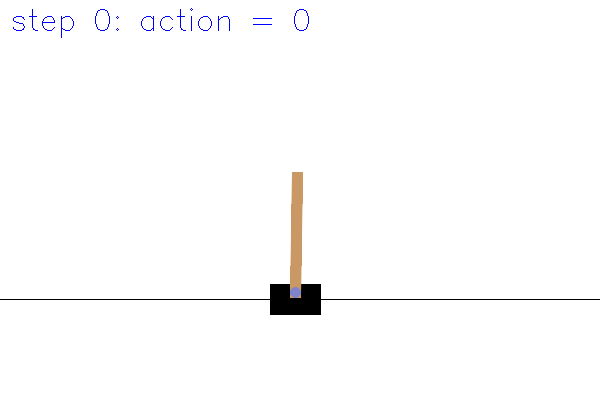

In [ ]:
import imageio; import cv2; from IPython.display import Image

# 환경 생성
env= gym.make("CartPole-v1", render_mode="rgb_array")
env= gym.wrappers.TimeLimit(env, max_episode_steps=100)
상태,_ = env.reset()

frames=[]  # 프레임 리스트 초기화

# 스텝별 프레임 생성
for step in range(100):
    행동=env.action_space.sample()
    상태, 보상, terminated, truncated, _ = env.step(행동)
    종료=terminated or truncated
    frame=env.render()  # 그림을 frame 변수에 저장
    frame=frame.copy()  # 꼭 복사해야 모든 프레임이 보존됨

    # ==== 스텝 번호와 행동을 텍스트로 삽입 ====
    텍스트_삽입=cv2.putText(
        frame.copy(),  # 원본 이미지 복사
        f"step {step}: action = {행동}",
        org=(10, 30),  # 텍스트 위치
        fontFace=cv2.FONT_HERSHEY_SIMPLEX,
        fontScale=1,color=(0, 0, 255),thickness=1 )

    frames.append(텍스트_삽입)
    if 종료:
        break
env.close()   # 환경 종료

# GIF 형태로 저장하고 출력하기
imageio.mimsave("cartpole.gif", frames, duration=0.2)  # duration은 프레임별 재생시간 (속도 조절)
Image(filename="cartpole.gif")  # GIF 파일로 저장

* OpenCV는 컴퓨터 비전과 이미지/영상 처리에서 널리 쓰이는 라이브러리입니다.
* JPEG, GIF, MP4 등 다양한 형식을 지원하고 색 변환, 필터링 등의 화상 처리 기능을 제공합니다.

[실습 22-05]

In [ ]:
# 라이브러리 설치
import numpy as np; import random; import gymnasium as gym
from gymnasium.wrappers import TimeLimit
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential, clone_model, load_model
from tensorflow.keras.layers import Dense, Input
from collections import deque
import warnings; warnings.filterwarnings('ignore')
from tensorflow.keras.losses import Huber

# 환경 생성
env = gym.make("CartPole-v1")
env = TimeLimit(env, max_episode_steps=100)
n_actions=2
n_states=4

# 하이퍼 파라미터
gamma = 0.99
e = 1; e_decay = 0.99; e_min=0.05
n_sample=128
n_episodes=500
TAU = 0.005
storage = deque(maxlen=5000)
min_step = 50; min_penalty=-100

# 예측 모델 생성
pred_model=Sequential([
    Input(shape=(n_states,)),
    Dense(16, activation="relu"),
    Dense(8,  activation="relu"),
    Dense(2) ])

pred_model.compile(loss=Huber(), optimizer="adam")

# 타깃 모델 생성
target_model=clone_model(pred_model)    # 예측_모델과 동일한 구조로 설정
target_model.set_weights(pred_model.get_weights())    # 예측_모델 파라미터와 동기화

최근_보상 = deque(maxlen=5)    # 최근 보상 저장(5개)
스텝_저장=[ ]


[실습 22-06]

In [ ]:
def soft_update(target_model, pred_model, tau):
    t_w = target_model.get_weights() # 타깃_모델의 가중치
    p_w = pred_model.get_weights()   # 예측_모델의 가중치

    new_weights = []
    for i in range(len(t_w)):        # 각 파라미터 별로 가중 평균
        new_weights.append((1 - tau) * t_w[i] + tau * p_w[i])

    target_model.set_weights(new_weights)

📌탐험과 활용 전략에 따른 행동 선택을 텐서로 처리하는 함수
* 메인 학습 루프 이전에 실행

In [ ]:
@tf.function
def select_action_tf(state, epsilon, pred_model, n_actions):
    state_tensor = tf.expand_dims(tf.cast(state, dtype=tf.float32), axis=0)
    q_values = pred_model(state_tensor)
    best_action = tf.argmax(q_values, axis=1, output_type=tf.int32)[0]
    random_action = tf.random.uniform(shape=(), maxval=n_actions, dtype=tf.int32)
    action = tf.where(
        tf.random.uniform(shape=()) < epsilon, random_action, best_action)
    return action

📌벨만 방정식으로  타깃 Q값을 생성하는 함수
* 메인 학습 루프 이전에 실행

In [ ]:
def target_bellman(state, next_state, action, reward, done):

    # -------------------------
    # 1. 모든 상태의 Q값 예측
    # -------------------------
    target = pred_model(state,training=False).numpy()

    # -------------------------
    # 2. 다음 상태의 최적 행동
    # -------------------------
    Q_next = pred_model(next_state,training=False).numpy()
    a_next = np.argmax(Q_next, axis=1)

    # ------------------------------------------
    # 3. 벨만방정식으로 선택된 행동의 타깃 수정
    # ------------------------------------------
    Q_target_next = target_model(next_state,training=False).numpy()
    for i in range(n_sample):
        target[i, action[i]] =reward[i]+ (gamma*Q_target_next[i, a_next[i]])*(done[i]==False)

    return target


[실습 22-07]

In [ ]:
for ep in range(n_episodes):
    상태, _ = env.reset()
    steps = 0
    총_보상 = 0
    종료 = False

    while 종료==False:
        행동 = select_action_tf(상태, e, pred_model,n_actions).numpy()

        다음_상태, 보상, terminated, truncated, _ = env.step(행동)

        종료 = terminated or truncated

        steps += 1

        # 조기 실패 패널티
        if terminated and (steps < min_step):
            보상 += min_penalty

        # 경험 데이터 저장
        storage.append((상태, 행동, 보상, 다음_상태, 종료))

        총_보상 += 보상

        # 현재 상태 갱신
        상태 = 다음_상태

        # =========================
        # 경험 리플레이 학습
        # =========================
        if len(storage) > n_sample:

            # 미니배치 샘플링
            batch=random.sample(storage, n_sample)

            # 데이터 분리
            (상태_벡터, 행동_벡터, 보상_벡터, 다음_상태_벡터, 종료_벡터) = zip(*batch)

            # 어레이 변환(자료형 지정 주의)
            상태_벡터 = np.asarray(상태_벡터, dtype=np.float32)
            행동_벡터 = np.asarray(행동_벡터, dtype=np.int32)
            보상_벡터 = np.asarray(보상_벡터, dtype=np.float32)
            다음_상태_벡터 = np.asarray(다음_상태_벡터, dtype=np.float32)
            종료_벡터 = np.asarray(종료_벡터, dtype=np.float32)

            # 타깃 Q값 계산
            Q_target=target_bellman(상태_벡터, 다음_상태_벡터, 행동_벡터, 보상_벡터, 종료_벡터)

            # 예측 모델 업데이트
            pred_model.train_on_batch(상태_벡터, Q_target)

            # 타깃 모델 업데이트
            soft_update(target_model,pred_model,TAU)

    # 탐험 비율 감소
    e = max(e_min, e * e_decay)

    # 결과 출력
    최근_보상.append(총_보상)
    최근_보상_평균 = np.mean(최근_보상)

    print(
        f"에피소드={ep:3} | "
        f"e={e:.3f} | "
        f"총_보상={총_보상:6} | "
        f"유지_스텝_수={steps:3}"
    )

    스텝_저장.append(steps)

    # 조기 종료 판정
    if 최근_보상_평균 >= 95:
        print("**조기 종료 조건 충족**")
        break

# 학습 완료된 모델 저장
pred_model.save('학습_모델_100.keras')

에피소드=  0 | e=0.990 | 총_보상= -86.0 | 유지_스텝_수= 14
에피소드=  1 | e=0.980 | 총_보상= -86.0 | 유지_스텝_수= 14
에피소드=  2 | e=0.970 | 총_보상= -84.0 | 유지_스텝_수= 16
에피소드=  3 | e=0.961 | 총_보상= -67.0 | 유지_스텝_수= 33
에피소드=  4 | e=0.951 | 총_보상= -79.0 | 유지_스텝_수= 21
에피소드=  5 | e=0.941 | 총_보상=  69.0 | 유지_스텝_수= 69
에피소드=  6 | e=0.932 | 총_보상= -62.0 | 유지_스텝_수= 38
에피소드=  7 | e=0.923 | 총_보상= -87.0 | 유지_스텝_수= 13
에피소드=  8 | e=0.914 | 총_보상= -84.0 | 유지_스텝_수= 16
에피소드=  9 | e=0.904 | 총_보상= -66.0 | 유지_스텝_수= 34
에피소드= 10 | e=0.895 | 총_보상= -75.0 | 유지_스텝_수= 25
에피소드= 11 | e=0.886 | 총_보상= -80.0 | 유지_스텝_수= 20
에피소드= 12 | e=0.878 | 총_보상= -79.0 | 유지_스텝_수= 21
에피소드= 13 | e=0.869 | 총_보상= -75.0 | 유지_스텝_수= 25
에피소드= 14 | e=0.860 | 총_보상= -84.0 | 유지_스텝_수= 16
에피소드= 15 | e=0.851 | 총_보상= -72.0 | 유지_스텝_수= 28
에피소드= 16 | e=0.843 | 총_보상= -86.0 | 유지_스텝_수= 14
에피소드= 17 | e=0.835 | 총_보상= -79.0 | 유지_스텝_수= 21
에피소드= 18 | e=0.826 | 총_보상= -91.0 | 유지_스텝_수=  9
에피소드= 19 | e=0.818 | 총_보상= -83.0 | 유지_스텝_수= 17
에피소드= 20 | e=0.810 | 총_보상= -86.0 | 유지_스텝_수= 14
에피소드= 21 | e=

[실습 22-08]

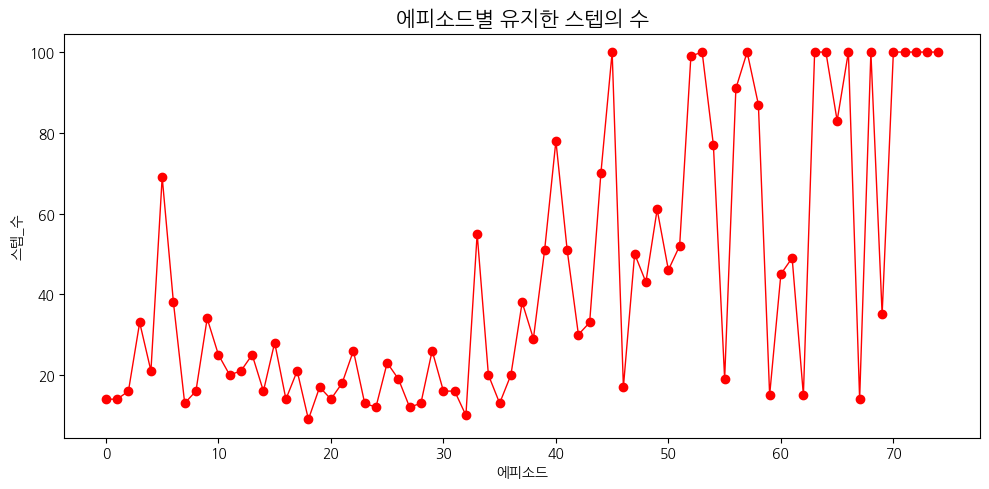

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(스텝_저장, "ro-", linewidth=1)

plt.title("에피소드별 유지한 스텝의 수", fontsize=15)
plt.xlabel("에피소드"); plt.ylabel("스텝_수")
plt.tight_layout()

plt.show()

📌 모델 성능 테스트
* 테스트를 할때는 탐험을 하지 않고 언제나 모델이 예측한 Q가 최대가 되는 행동을 선택합니다.

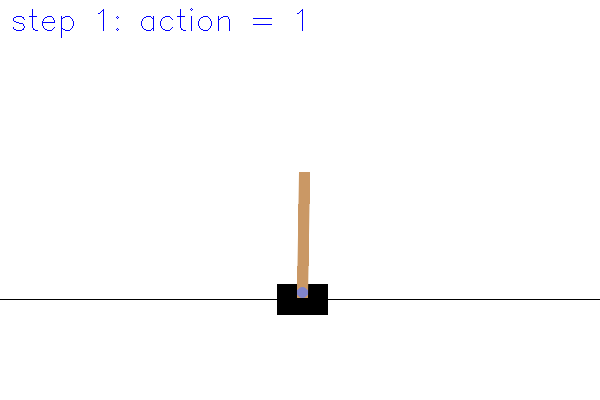

In [ ]:
import imageio
import numpy as np
import cv2  # 텍스트 삽입용
from IPython.display import Image
from tensorflow.keras.models import Sequential, load_model

# 저장된 모델 불러오기
test_model=load_model('학습_모델_100.keras')

env = gym.make("CartPole-v1", render_mode="rgb_array")
env = TimeLimit(env, max_episode_steps=100)

상태,_ = env.reset()

frames = []
steps=0
종료=False

while 종료==False:  # 종료될 때까지 반복

    # 학습된 모델로 Q값 예측
    Q = test_model.predict(상태.reshape(1,-1), verbose=0)

    # 최적 행동 선택
    행동 = np.argmax(Q)

    상태, 보상, terminated, truncated, info = env.step(행동)
    종료= terminated or truncated

    # 프레임 생성
    frame = env.render(); frame = frame.copy()
    텍스트_삽입=cv2.putText(
        frame.copy(),
        f"step {steps+1}: action = {행동}",
        org=(10, 30),
        fontFace=cv2.FONT_HERSHEY_SIMPLEX,
        fontScale=1,color=(0, 0, 255),thickness=1 )
    frames.append(텍스트_삽입)
    steps=steps+1

env.close()

# GIF 저장과 출력
imageio.mimsave("모델_성능_100.gif", frames, duration=0.1)
Image(filename="모델_성능_100.gif")

**[참고] Gymnasium에서 제공하는 기타 강화학습 환경 소개**
* https://gymnasium.farama.org/index.html


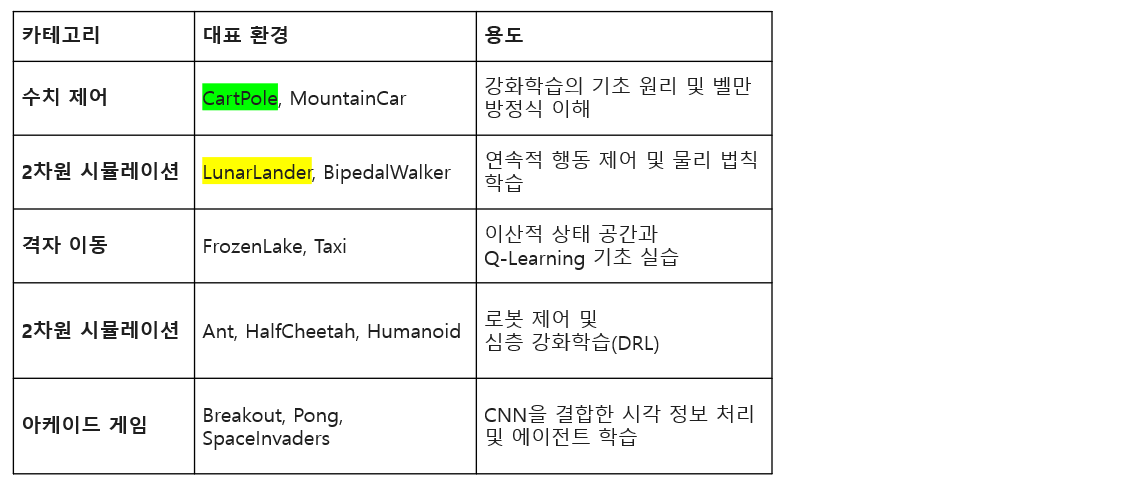

다른 환경도 도전해봅시다!!